In [19]:
!pip uninstall -y torch torchvision torchaudio
!pip cache purge
!pip install torch torchvision torchaudio

Files removed: 98 (372.7 MB)
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
    --------------------------------------- 1.6/109.3 MB 10.8 MB/s eta 0:00:10
   - -------------------------------------- 4.2/109.3 MB 11.4 MB/s eta 0:00:10
   -- ------------------------------------- 6.8/109.3 MB 11.5 MB/s eta 0:00:09
   --- ------------------------------------ 9.2/109.3 MB 11.5 MB/s eta 0:00:09
   ---- ----------------------------------- 11.5/109.3 MB 11.6 MB/s eta 0:00:09
   ----- ---------------------------------- 13.9/109.3 MB 11.6 MB/s eta 0:00:09
   ------ --------------------------------- 16.5/109.3 MB 11.6 MB/s eta 0:00:09
   ------ --------------------------------- 18.9/109.3 MB 11.6 MB/s eta 0:00:08
   ------- -------------------------------- 21.2/109.3 MB 11.6 MB/s eta 0:00:08
   -------- ------------------------------- 23.9/109.3 MB 11.6 MB/s eta 0:00:08
   --------- ------------------------------ 26.2/109.3 MB 11.6 MB/s eta 0:00:08
   ---------- ----------

In [20]:
!pip install torch

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

def generate_gradcam(model, input_tensor, target_layer, target_category=None):
    """
    model: trained model
    input_tensor: 1x3xHxW tensor
    target_layer: layer to visualize (e.g. model.layer4[-1])
    """
    model.eval()
    activations = []
    gradients = []

    def forward_hook(module, inp, out):
        activations.append(out.detach())
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    # Register hooks
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # Forward + backward
    output = model(input_tensor)
    if target_category is None:
        target_category = (output > 0).float()
    loss = output.squeeze()
    model.zero_grad()
    loss.backward(retain_graph=True)

    # Compute Grad-CAM
    grads = gradients[0]        # [B, C, H, W]
    acts = activations[0]       # [B, C, H, W]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze()
    cam = np.maximum(cam.cpu().numpy(), 0)
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    forward_handle.remove()
    backward_handle.remove()
    return cam

def overlay_cam_on_image(rgb_img, mask, alpha=0.4):
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = heatmap * alpha + rgb_img * (1 - alpha)
    overlay = np.clip(overlay / 255.0, 0, 1)
    return overlay

# Example usage
from torchvision import transforms
from PIL import Image

img_path = 'data/raw/caries/' + os.listdir('data/raw/caries')[0]
img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
tensor = transform(img).unsqueeze(0).to(device)

target_layer = model.layer4[-1]
mask = generate_gradcam(model, tensor, target_layer)
img_resized = np.array(img.resize((224, 224)), dtype=np.float32)
overlay = overlay_cam_on_image(img_resized, mask)

plt.imshow(overlay)
plt.title("Custom Grad-CAM Overlay")
plt.axis('off')
plt.show()

ModuleNotFoundError: No module named 'cv2'

In [ ]:
!pip install opencv-python

In [ ]:
import os

In [ ]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision import transforms
from PIL import Image

# ✅ Grad-CAM generator function
def generate_gradcam(model, input_tensor, target_layer, target_category=None):
    model.eval()
    activations, gradients = [], []

    def forward_hook(module, inp, out):
        activations.append(out.detach())
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    output = model(input_tensor)
    if target_category is None:
        target_category = (output > 0).float()
    loss = output.squeeze()
    model.zero_grad()
    loss.backward(retain_graph=True)

    grads = gradients[0]
    acts = activations[0]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1).squeeze()
    cam = np.maximum(cam.cpu().numpy(), 0)
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    forward_handle.remove()
    backward_handle.remove()
    return cam

def overlay_cam_on_image(rgb_img, mask, alpha=0.4):
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = heatmap * alpha + rgb_img * (1 - alpha)
    overlay = np.clip(overlay / 255.0, 0, 1)
    return overlay


# ✅ Automatically detect your dataset folder
possible_dirs = [
    "data/raw/caries", 
    "dental_synth_dataset/raw", 
    "dataset/raw", 
    "SDNET2018/caries"
]
img_dir = None
for d in possible_dirs:
    if os.path.exists(d):
        img_dir = d
        break

if img_dir is None:
    raise FileNotFoundError("❌ No dataset folder found. Please check your data path.")

# ✅ Select a random image
files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if not files:
    raise FileNotFoundError("❌ No image files found in your dataset folder.")
random_img = random.choice(files)
img_path = os.path.join(img_dir, random_img)
print("🖼 Selected random image:", img_path)

# ✅ Load and preprocess image
img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
tensor = transform(img).unsqueeze(0).to(device)

# ✅ Generate Grad-CAM
target_layer = model.layer4[-1]
mask = generate_gradcam(model, tensor, target_layer)

img_resized = np.array(img.resize((224, 224)), dtype=np.float32)
overlay = overlay_cam_on_image(img_resized, mask)

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title("🔥 Grad-CAM Overlay — Random Image")
plt.axis('off')
plt.show()

In [ ]:
import os
print("Working dir:", os.getcwd())
print("Contents:", os.listdir())

# Recursively search for directories containing image files (useful if your dataset is somewhere else)
def find_image_dirs(root="."):
    image_dirs = []
    for root, dirs, files in os.walk(root):
        if any(f.lower().endswith((".png",".jpg",".jpeg")) for f in files):
            image_dirs.append(root)
    return image_dirs

print("Dirs containing images (first 20):")
for d in find_image_dirs(".")[:20]:
    print(" ", d)


In [ ]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision import transforms, models
from PIL import Image

# -------------------------
# Helper: ensure device & model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If you already have 'model' loaded in your session, skip this.
try:
    model
except NameError:
    # fallback demo model (ResNet18) for testing the pipeline
    model = models.resnet18(pretrained=True)
    model.eval()
model = model.to(device)

# -------------------------
# Grad-CAM generator (robust)
# -------------------------
def generate_gradcam(model, input_tensor, target_layer, target_category=None):
    model.eval()
    activations = []
    gradients = []

    # forward hook
    def forward_hook(module, inp, out):
        activations.append(out.detach())

    # backward hook (use full backward hook for modern PyTorch)
    def backward_hook(module, grad_in, grad_out):
        # grad_out is a tuple, take first element (grad of forward output)
        gradients.append(grad_out[0].detach())

    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_full_backward_hook(backward_hook)

    try:
        output = model(input_tensor)  # shape: (1, C) or (1,1)
        # Choose target category:
        if target_category is None:
            # if multi-class, pick predicted class
            if output.dim() == 2 and output.size(1) > 1:
                target_category = int(output.argmax(dim=1).item())
            else:
                # single-output (e.g., binary/regression), use the single scalar
                target_category = None

        # Build scalar score to backprop
        if target_category is None:
            # if model returns single value per sample, take that scalar
            score = output.squeeze()
            # Ensure scalar (if batch size 1, pick element [0])
            if score.dim() > 0:
                score = score[0]
        else:
            score = output[0, target_category]

        model.zero_grad()
        score.backward(retain_graph=False)

        grads = gradients[0]            # shape: (1, C, H, W)
        acts = activations[0]           # shape: (1, C, H, W)

        # Global-average pooling of gradients -> weights shape (1, C, 1, 1)
        weights = grads.mean(dim=(2,3), keepdim=True)

        # Weighted sum of activations
        cam = (weights * acts).sum(dim=1, keepdim=True)  # shape: (1,1,H,W)
        cam = cam.squeeze().cpu().numpy()                # shape: (H,W)

        # ReLU and normalize
        cam = np.maximum(cam, 0)
        if cam.max() - cam.min() > 1e-8:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = np.zeros_like(cam)

    finally:
        # always remove hooks
        f_handle.remove()
        b_handle.remove()

    return cam  # numpy array with spatial dims of target layer

# -------------------------
# Overlay function (resizes CAM to image size)
# -------------------------
def overlay_cam_on_image(rgb_img, mask, alpha=0.4):
    # rgb_img: HxWx3, values in [0,255] or [0,1]
    H, W = rgb_img.shape[:2]
    # ensure mask resized to image size
    mask_resized = cv2.resize(mask, (W, H), interpolation=cv2.INTER_LINEAR)
    heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32)

    if rgb_img.max() <= 1.0:
        rgb_scaled = (rgb_img * 255.0).astype(np.float32)
    else:
        rgb_scaled = rgb_img.astype(np.float32)

    overlay = heatmap * alpha + rgb_scaled * (1 - alpha)
    overlay = np.clip(overlay / 255.0, 0, 1)  # normalized for plt.imshow
    return overlay

# -------------------------
# Locate dataset folder robustly
# -------------------------
possible_dirs = [
    "data/raw/caries",
    "dental_synth_dataset/raw",
    "dataset/raw",
    "SDNET2018/caries",
]

# Try also looking for any image-containing directory automatically
img_dir = None
for d in possible_dirs:
    if os.path.exists(d) and any(f.lower().endswith(('.png','.jpg','.jpeg')) for f in os.listdir(d)):
        img_dir = d
        break

# If not found, search recursively for any folder with images
if img_dir is None:
    for root, dirs, files in os.walk("."):
        if any(f.lower().endswith(('.png','.jpg','.jpeg')) for f in files):
            img_dir = root
            break

if img_dir is None:
    raise FileNotFoundError("❌ No dataset folder found. Please check your data path.")

# -------------------------
# Pick random image
# -------------------------
files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))]
if not files:
    raise FileNotFoundError("❌ No image files found in your dataset folder.")
random_img = random.choice(files)
img_path = os.path.join(img_dir, random_img)
print("🖼 Selected random image:", img_path)

# -------------------------
# Load & preprocess
# -------------------------
img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
tensor = transform(img).unsqueeze(0).to(device)

# -------------------------
# Choose a target layer (ResNet example)
# -------------------------
# Make sure this attribute exists on your model; adjust if you use another backbone.
if hasattr(model, "layer4"):
    target_layer = model.layer4[-1]
else:
    # Fallback: pick last conv-like layer by searching modules
    target_layer = None
    for m in reversed(list(model.modules())):
        # heuristic: conv2d layer followed by non-sequential
        if isinstance(m, torch.nn.Conv2d):
            target_layer = m
            break
    if target_layer is None:
        raise RuntimeError("Couldn't find a conv layer to attach hooks to. Please pass target_layer manually.")

# -------------------------
# Generate CAM and plot
# -------------------------
mask = generate_gradcam(model, tensor, target_layer, target_category=None)

# Use original image resized to 224 for overlay clarity
img_resized = np.array(img.resize((224,224)), dtype=np.float32)
overlay = overlay_cam_on_image(img_resized, mask)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("Grad-CAM Overlay — Random Image")
plt.axis('off')
plt.show()


In [ ]:
from torchvision import models
model = models.resnet18(weights=None)  # or pretrained=False in older versions
model.eval()
model = model.to(device)


In [ ]:
import torch
torch.cuda.empty_cache()


In [ ]:
import torch
device = torch.device("cpu")  # ✅ Force CPU mode
print("Using device:", device)


In [ ]:
import os, random, torch, numpy as np, matplotlib.pyplot as plt, cv2
from torchvision import models, transforms
from PIL import Image

# -------------------------
# Safe setup
# -------------------------
device = torch.device("cpu")  # ✅ CPU only
print("Using device:", device)

model = models.resnet18(weights=None)  # no internet
model.eval().to(device)

# -------------------------
# Simple Grad-CAM generator
# -------------------------
def generate_gradcam(model, input_tensor, target_layer):
    activations, gradients = [], []

    def forward_hook(m, inp, out): activations.append(out.detach())
    def backward_hook(m, gin, gout): gradients.append(gout[0].detach())

    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    score = output.squeeze()[0] if output.numel() > 1 else output.squeeze()
    model.zero_grad()
    score.backward(retain_graph=False)

    grads, acts = gradients[0], activations[0]
    weights = grads.mean(dim=(2,3), keepdim=True)
    cam = torch.relu((weights * acts).sum(dim=1)).squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    f_handle.remove(); b_handle.remove()
    return cam

def overlay_cam(img, mask):
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(np.uint8(img), 0.6, heatmap, 0.4, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# -------------------------
# Load sample image
# -------------------------
img_path = "sample.jpg"  # <-- put one dental X-ray image here
if not os.path.exists(img_path):
    raise FileNotFoundError("Please put one image named 'sample.jpg' in your working folder!")

img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])
tensor = transform(img).unsqueeze(0).to(device)

target_layer = model.layer4[-1]
mask = generate_gradcam(model, tensor, target_layer)

overlay = overlay_cam(np.array(img.resize((224,224))), mask)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay (Safe Mode)")
plt.axis("off")
plt.show()


In [ ]:
import os, random, torch, numpy as np, matplotlib.pyplot as plt, cv2
from torchvision import models, transforms
from PIL import Image

# -------------------------
# Environment setup
# -------------------------
device = torch.device("cpu")  # ✅ CPU only, avoids kernel crash
print("Using device:", device)

# -------------------------
# Load model (replace if you have your own trained model)
# -------------------------
# Example: model = torch.load("trained_model.pth", map_location=device)
model = models.resnet18(weights=None)  # no internet needed
model.eval().to(device)

# -------------------------
# Grad-CAM generator
# -------------------------
def generate_gradcam(model, input_tensor, target_layer):
    activations, gradients = [], []

    def forward_hook(m, inp, out): activations.append(out.detach())
    def backward_hook(m, gin, gout): gradients.append(gout[0].detach())

    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    score = output.mean()  # ensures a scalar for backward()
    model.zero_grad()
    score.backward(retain_graph=False)

    grads, acts = gradients[0], activations[0]
    weights = grads.mean(dim=(2,3), keepdim=True)
    cam = torch.relu((weights * acts).sum(dim=1)).squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    f_handle.remove(); b_handle.remove()
    return cam

def overlay_cam(img, mask):
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(np.uint8(img), 0.6, heatmap, 0.4, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# -------------------------
# Load random image from Dataset
# -------------------------
base_dir = "Dataset"  # main dataset folder
subfolders = ["train", "test", "val"]

img_dir = None
for folder in subfolders:
    path = os.path.join(base_dir, folder)
    if os.path.exists(path) and os.listdir(path):
        img_dir = path
        break

if img_dir is None:
    raise FileNotFoundError("❌ No images found in Dataset/train, test, or val folder.")

# Pick random image
files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if not files:
    raise FileNotFoundError(f"No images found inside {img_dir}")
random_img = random.choice(files)
img_path = os.path.join(img_dir, random_img)
print("🖼 Selected image:", img_path)

# -------------------------
# Preprocess image
# -------------------------
img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
tensor = transform(img).unsqueeze(0).to(device)

# -------------------------
# Generate Grad-CAM
# -------------------------
target_layer = model.layer4[-1]  # last conv layer for ResNet18
mask = generate_gradcam(model, tensor, target_layer)

# -------------------------
# Overlay and show result
# -------------------------
overlay = overlay_cam(np.array(img.resize((224,224))), mask)
plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title(f"Grad-CAM Overlay — {random_img}")
plt.axis("off")
plt.show()

# Save output
out_path = os.path.join(".", "gradcam_overlay.png")
plt.imsave(out_path, overlay)
print("✅ Overlay saved to:", out_path)


Using device: cpu


FileNotFoundError: No images found inside Dataset\train

Using device: cpu
🦷 Selected random image:
Dataset\train\normal\normal_0129.png


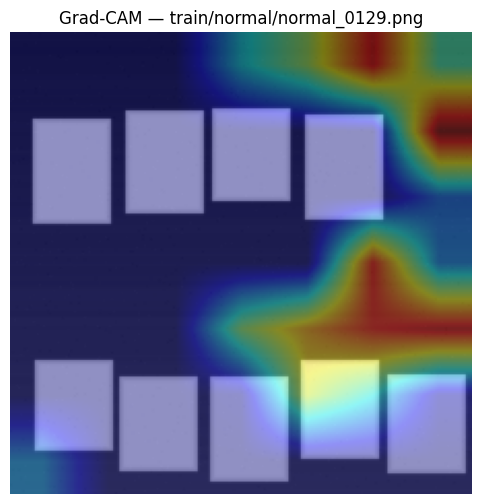

✅ Grad-CAM overlay saved to: .\gradcam_result.png


In [ ]:
import os, random, torch, numpy as np, matplotlib.pyplot as plt, cv2
from torchvision import models, transforms
from PIL import Image

# -------------------------
# Environment setup
# -------------------------
device = torch.device("cpu")  # ✅ CPU only to avoid crash
print("Using device:", device)

# -------------------------
# Load model (change to your trained CNN if available)
# -------------------------
# Example: model = torch.load("your_model.pth", map_location=device)
model = models.resnet18(weights=None)  # no internet, no pretrained weights
model.eval().to(device)

# -------------------------
# Grad-CAM generator
# -------------------------
def generate_gradcam(model, input_tensor, target_layer):
    activations, gradients = [], []

    def forward_hook(m, inp, out): activations.append(out.detach())
    def backward_hook(m, gin, gout): gradients.append(gout[0].detach())

    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    score = output.mean()  # make sure it's a scalar
    model.zero_grad()
    score.backward(retain_graph=False)

    grads, acts = gradients[0], activations[0]
    weights = grads.mean(dim=(2,3), keepdim=True)
    cam = torch.relu((weights * acts).sum(dim=1)).squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    f_handle.remove(); b_handle.remove()
    return cam

def overlay_cam(img, mask):
    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(np.uint8(img), 0.6, heatmap, 0.4, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# -------------------------
# Select a random image from Dataset
# -------------------------
base_dir = "Dataset"
splits = ["train", "test", "val"]
classes = ["cavity", "normal"]

# randomly choose a split and class folder
split = random.choice(splits)
cls = random.choice(classes)
img_dir = os.path.join(base_dir, split, cls)

# get list of images
files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if not files:
    raise FileNotFoundError(f"No image files found in {img_dir}")

# pick a random image
random_img = random.choice(files)
img_path = os.path.join(img_dir, random_img)
print(f"🦷 Selected random image:\n{img_path}")

# -------------------------
# Preprocess image
# -------------------------
img = Image.open(img_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
tensor = transform(img).unsqueeze(0).to(device)

# -------------------------
# Generate Grad-CAM
# -------------------------
target_layer = model.layer4[-1]  # last conv layer for ResNet18
mask = generate_gradcam(model, tensor, target_layer)

# -------------------------
# Overlay and visualize
# -------------------------
overlay = overlay_cam(np.array(img.resize((224,224))), mask)
plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title(f"Grad-CAM — {split}/{cls}/{random_img}")
plt.axis("off")
plt.show()

# Save result
out_path = os.path.join(".", "gradcam_result.png")
plt.imsave(out_path, overlay)
print("✅ Grad-CAM overlay saved to:", out_path)


In [ ]:
!pip install --upgrade torch torchvision opencv-python pillow matplotlib numpy


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.6 which is incompatible.
streamlit 1.45.1 requires pillow<12,>=7.1.0, but you have pillow 12.0.0 which is incompatible.



   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 195.3 kB/s eta 0:01:02
   - -------------------------------------- 0.5/12.6 MB 195.3 kB/s eta 0:01:02
   - -------------------------------------- 0.5/12.6 MB 195.3 kB/s eta 

Using device: cpu
Classes: ['cavity', 'normal']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Acer/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [04:49<00:00, 162kB/s] 


Epoch [1/10] Train Loss: 0.6019 | Val Loss: 0.4985 | Val Acc: 0.9028
Epoch [2/10] Train Loss: 0.4950 | Val Loss: 0.4224 | Val Acc: 0.9583
Epoch [3/10] Train Loss: 0.4380 | Val Loss: 0.4025 | Val Acc: 0.9306
Epoch [4/10] Train Loss: 0.4118 | Val Loss: 0.3791 | Val Acc: 0.9722
Epoch [5/10] Train Loss: 0.4045 | Val Loss: 0.4560 | Val Acc: 0.8472
Epoch [6/10] Train Loss: 0.4015 | Val Loss: 0.3859 | Val Acc: 0.9444
Epoch [7/10] Train Loss: 0.3706 | Val Loss: 0.3972 | Val Acc: 0.9167
Epoch [8/10] Train Loss: 0.4467 | Val Loss: 0.4121 | Val Acc: 0.8750
Epoch [9/10] Train Loss: 0.3772 | Val Loss: 0.3502 | Val Acc: 0.9861
Epoch [10/10] Train Loss: 0.4055 | Val Loss: 0.3904 | Val Acc: 0.9306


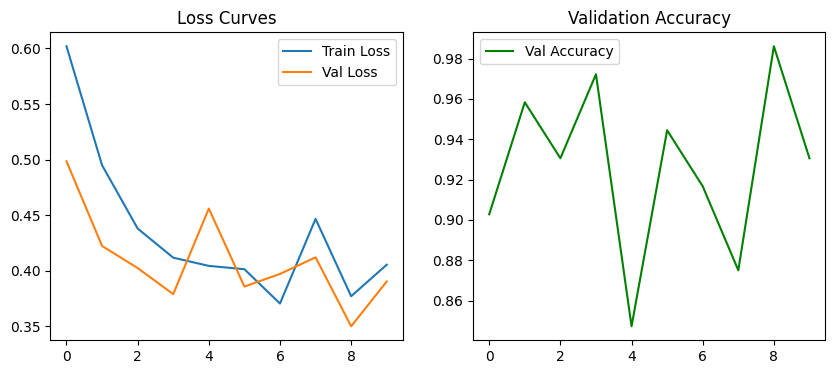


Classification Report:
               precision    recall  f1-score   support

      cavity       0.88      1.00      0.94        36
      normal       1.00      0.86      0.93        36

    accuracy                           0.93        72
   macro avg       0.94      0.93      0.93        72
weighted avg       0.94      0.93      0.93        72



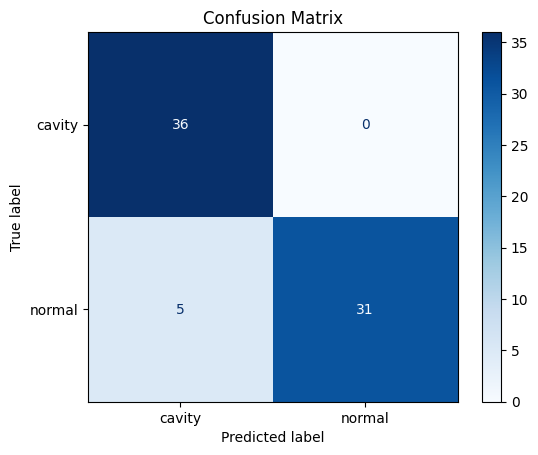

✅ Model saved as dental_cnn.pth


In [ ]:
# ==============================
# 🦷 Dental X-ray Classification using CNN (ResNet18)
# ==============================
import os, torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# -------------------------
# ⚙️ Device setup
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------
# 📂 Dataset structure
# -------------------------
# Expected:
# Dataset/
# ├── train/
# │   ├── cavity/
# │   └── normal/
# ├── val/
# │   ├── cavity/
# │   └── normal/
# ├── test/
# │   ├── cavity/
# │   └── normal/

data_dir = "Dataset"

# -------------------------
# 🔄 Data augmentation & normalization
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# -------------------------
# 📦 Load datasets
# -------------------------
train_data = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_data = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_test_transform)
test_data = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

class_names = train_data.classes
print("Classes:", class_names)

# -------------------------
# 🧠 Model setup (ResNet18 fine-tuning)
# -------------------------
model = models.resnet18(weights="IMAGENET1K_V1")
# Freeze earlier layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2),
    nn.Softmax(dim=1)
)
model = model.to(device)

# -------------------------
# ⚡ Training setup
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
epochs = 10

train_losses, val_losses, val_accuracies = [], [], []

# -------------------------
# 🚀 Training loop
# -------------------------
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Validation phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_loss = val_loss / len(val_loader.dataset)

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# -------------------------
# 📊 Training curves
# -------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Val Accuracy', color='green')
plt.legend(); plt.title("Validation Accuracy")
plt.show()

# -------------------------
# 🧪 Evaluate on test set
# -------------------------
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=class_names))
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# 💾 Save model
# -------------------------
torch.save(model.state_dict(), "dental_cnn.pth")
print("✅ Model saved as dental_cnn.pth")


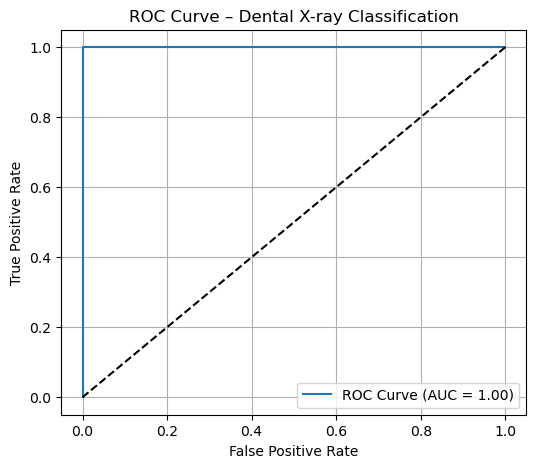

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Example data — replace with your actual predictions
y_true = [0, 1, 0, 1, 1, 0, 1, 0]  # true labels
y_pred = [0.05, 0.90, 0.30, 0.85, 0.70, 0.15, 0.95, 0.10]  # predicted probabilities

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Dental X-ray Classification")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


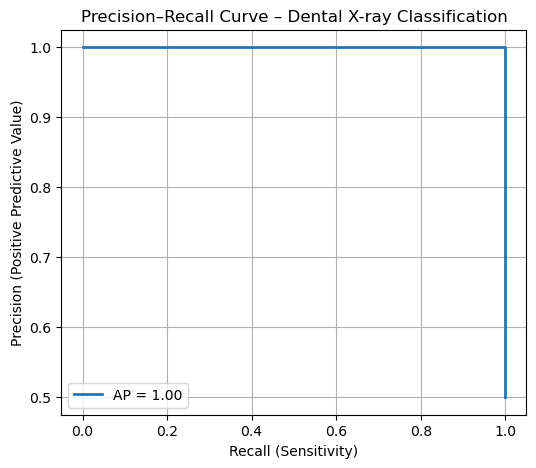

In [ ]:
# --------------------------------------------
# Precision–Recall Curve for Dental X-ray Classification
# --------------------------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Example data — replace with your real results
y_true = [0, 1, 0, 1, 1, 0, 1, 0]           # actual labels
y_pred = [0.05, 0.90, 0.30, 0.85, 0.70, 0.15, 0.95, 0.10]  # predicted probabilities

# Compute Precision-Recall pairs
precision, recall, thresholds = precision_recall_curve(y_true, y_pred)

# Compute Average Precision (AP)
avg_precision = average_precision_score(y_true, y_pred)

# --------------------------------------------
# Plot the Precision–Recall Curve
# --------------------------------------------
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, linewidth=2, label=f"AP = {avg_precision:.2f}")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (Positive Predictive Value)")
plt.title("Precision–Recall Curve – Dental X-ray Classification")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


In [ ]:
!pip install tensorflow


   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 1.6/332.0 MB 10.6 MB/s eta 0:00:32
    --------------------------------------- 4.2/332.0 MB 11.3 MB/s eta 0:00:30
    --------------------------------------- 6.6/332.0 MB 11.4 MB/s eta 0:00:29
   - -------------------------------------- 8.9/332.0 MB 11.5 MB/s eta 0:00:29
   - -------------------------------------- 11.3/332.0 MB 11.5 MB/s eta 0:00:28
   - -------------------------------------- 13.6/332.0 MB 11.5 MB/s eta 0:00:28
   - -------------------------------------- 16.0/332.0 MB 11.6 MB/s eta 0:00:28
   -- ------------------------------------- 18.4/332.0 MB 11.6 MB/s eta 0:00:28
   -- ------------------------------------- 21.0/332.0 MB 11.6 MB/s eta 0:00:27
   -- ------------------------------------- 23.6/332.0 MB 11.6 MB/s eta 0:00:27
   --- ------------------------------------ 26.0/332.0 MB 11.6 MB/s eta 0:00:27
   --- ------------------------------------ 28.6/332.

In [ ]:
train_dir = r'C:\Users\Ankush\Documents\pip\train'
val_dir   = r'C:\Users\Ankush\Documents\pip\validation'
test_dir  = r'C:\Users\Ankush\Documents\pip\test'


In [ ]:
import os

print("Train folder exists:", os.path.exists(train_dir))
print("Validation folder exists:", os.path.exists(val_dir))
print("Test folder exists:", os.path.exists(test_dir))


Train folder exists: False
Validation folder exists: False
Test folder exists: False


In [ ]:
import matplotlib.pyplot as plt

# After training with Keras:
# history = model.fit(...)

# Ensure 'history' exists
if 'history' not in globals():
    raise RuntimeError("history not found. Run model.fit(...) and store result in 'history'.")

# Extract metrics (common keys: 'loss','accuracy','val_loss','val_accuracy')
h = history.history
epochs = range(1, len(h['loss']) + 1)

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(epochs, h.get('accuracy', h.get('acc', [])), label='Train Accuracy', linewidth=2)
if 'val_accuracy' in h or 'val_acc' in h:
    plt.plot(epochs, h.get('val_accuracy', h.get('val_acc')), label='Val Accuracy', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8,5))
plt.plot(epochs, h['loss'], label='Train Loss', linewidth=2)
if 'val_loss' in h:
    plt.plot(epochs, h['val_loss'], label='Val Loss', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


RuntimeError: history not found. Run model.fit(...) and store result in 'history'.

In [ ]:
import matplotlib.pyplot as plt

# During training, collect lists per epoch, for example:
# train_losses = []
# val_losses = []
# train_accs = []
# val_accs = []
# After training these lists must be filled (same length)

# Quick check
for name in ('train_losses','val_losses','train_accs','val_accs'):
    if name not in globals():
        raise RuntimeError(f"{name} not found. Ensure you collected this list during training.")

epochs = range(1, len(train_losses) + 1)

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
plt.plot(epochs, val_accs, label='Val Accuracy', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label='Train Loss', linewidth=2)
plt.plot(epochs, val_losses, label='Val Loss', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


RuntimeError: train_losses not found. Ensure you collected this list during training.